In [154]:
import pandas as pd
import arviz as az
import os.path as op

In [155]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [156]:
bids_folder = '/data/ds-risk'

In [157]:
parameter_labels = ['n1_evidence_sd', 'n2_evidence_sd', 'risky_prior_mu', 'safe_prior_mu', 'risky_prior_std', 'safe_prior_std']

In [194]:
keys = []

results = []

for parameter_source, use_calibrated_design in [('prior', False), ('data', False), ('data', True)]:
    for simulation_ix in range(1, 11):

        print(parameter_source, use_calibrated_design, simulation_ix)

        key = f'source-{parameter_source}'
        if use_calibrated_design:
            key += '_calibrateddesign'
        key += f'_{simulation_ix}'

        target_dir = op.join(bids_folder, 'derivatives', 'parameter_recovery')
        generating_parameters = pd.read_csv(op.join(target_dir, f'simulated_parameters_{key}.tsv'), sep='\t', index_col=[0,])
        generating_parameters.columns.name = 'parameter'
        df = pd.read_csv(op.join(target_dir, f'simulated_data_{key}.tsv'), sep='\t')

        idata = az.from_netcdf(op.join(target_dir, f'posterior_samples_{key}.nc'))
        estimates = idata.posterior[parameter_labels].to_dataframe()
        estimates.columns.name = 'parameter'
        hdi = estimates.groupby('subject').apply(lambda d: pd.DataFrame(az.hdi(d.values), index=pd.Index(parameter_labels, name='parameter'), columns=['hdi025', 'hdi975']))
        means = estimates.groupby('subject').mean()
        estimate_summary = means.stack().to_frame('mean').join(hdi)

        results.append(estimate_summary.join(generating_parameters.stack().to_frame('ground truth')))
        keys.append((parameter_source, use_calibrated_design, simulation_ix))

results = pd.concat(results, keys=keys, names=['parameter_source', 'use_calibrated_design', 'simulation_ix'])

prior False 1
prior False 2
prior False 3
prior False 4
prior False 5
prior False 6
prior False 7
prior False 8
prior False 9
prior False 10
data False 1
data False 2
data False 3
data False 4
data False 5
data False 6
data False 7
data False 8
data False 9
data False 10
data True 1
data True 2
data True 3
data True 4
data True 5
data True 6
data True 7
data True 8
data True 9
data True 10


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_56441/3209449366.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  g = sns.lmplot(x='ground truth', y='mean', data=results.loc[('data', True)].reset_index(), hue='simulation_ix', palette=['k'], col='parameter', col_wrap=3,
/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


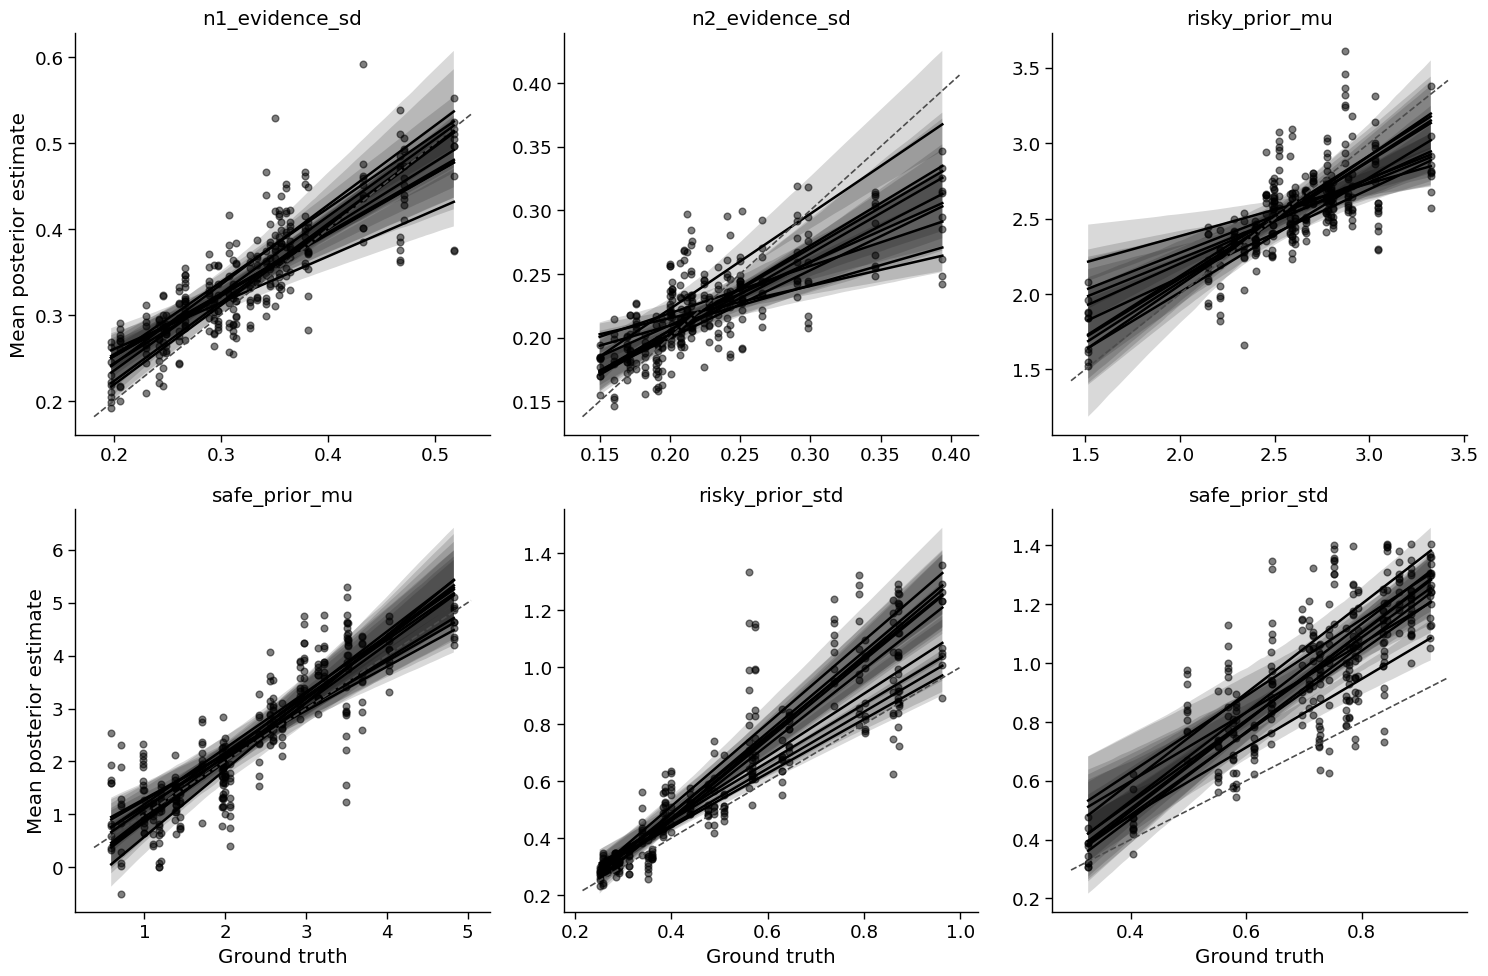

In [171]:
import seaborn as sns
sns.set_context('paper', font_scale=1.5)


g = sns.lmplot(x='ground truth', y='mean', data=results.loc[('data', True)].reset_index(), hue='simulation_ix', palette=['k'], col='parameter', col_wrap=3,
               legend=False,scatter_kws={'alpha': 0.5}, sharey=False, sharex=False)
g.set_xlabels('Ground truth')
g.set_ylabels('Mean posterior estimate')

g.set_titles('{col_name}')
# Identity line for each plot:
for ax in g.axes.flat:
    ax.plot(ax.get_xlim(), ax.get_xlim(), ls="--", c=".3")

In [174]:
results

mean  \
parameter_source use_calibrated_design simulation_ix subject parameter                   
prior            False                 1             1       n1_evidence_sd   0.123511   
                                                             n2_evidence_sd   0.127022   
                                                             risky_prior_mu   2.766658   
                                                             safe_prior_mu    2.172511   
                                                             risky_prior_std  2.926961   
...                                                                                ...   
data             True                  10            32      n2_evidence_sd   0.191662   
                                                             risky_prior_mu   1.523975   
                                                             safe_prior_mu    3.886256   
                                                             risky_prior_std  0.302404   
                                                             safe_prior_std   0.610630   

                                                                                 hdi025  \
parameter_source use_calibrated_design simulation_ix subject parameter                    
prior            False                 1             1       n1_evidence_sd    0.037146   
                                                             n2_evidence_sd    0.038387   
                                                             risky_prior_mu   -1.279138   
                                                             safe_prior_mu   -12.262310   
                                                             risky_prior_std   0.921811   
...                                                                                 ...   
data             True                  10            32      n2_evidence_sd    0.135069   
                                                             risky_prior_mu    0.915939   
                                                             safe_prior_mu     2.120416   
                                                             risky_prior_std   0.199602   
                                                             safe_prior_std    0.289566   

                                                                                 hdi975  \
parameter_source use_calibrated_design simulation_ix subject parameter                    
prior            False                 1             1       n1_evidence_sd    0.207535   
                                                             n2_evidence_sd    0.204593   
                                                             risky_prior_mu    6.379051   
                                                             safe_prior_mu    13.325052   
                                                             risky_prior_std   4.876165   
...                                                                                 ...   
data             True                  10            32      n2_evidence_sd    0.252788   
                                                             risky_prior_mu    2.027409   
                                                             safe_prior_mu     5.835432   
                                                             risky_prior_std   0.409004   
                                                             safe_prior_std    0.988786   

                                                                              ground truth  
parameter_source use_calibrated_design simulation_ix subject parameter                      
prior            False                 1             1       n1_evidence_sd       0.016482  
                                                             n2_evidence_sd       0.198959  
                                                             risky_prior_mu       3.817769  
                                                             safe_prior_mu    

Text(44.65104166666666, 0.5, 'Generating')

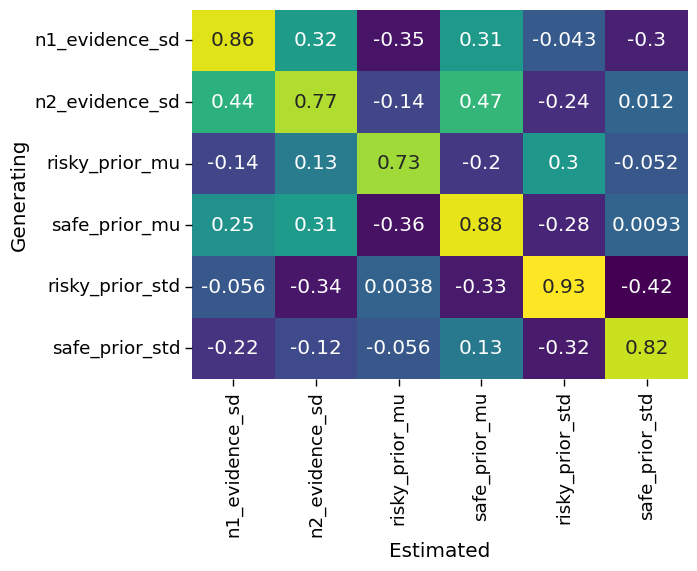

In [185]:
import matplotlib.pyplot as plt
r = results.groupby(['parameter_source', 'use_calibrated_design', 'simulation_ix']).apply(lambda x: x.unstack('parameter')[['mean', 'ground truth']].corr().loc[['ground truth'], ['mean']])

r = r.groupby(['parameter_source', 'use_calibrated_design', 'parameter']).mean()

g = sns.heatmap(r.loc[('data', True)].droplevel(0, axis=1).loc[parameter_labels, parameter_labels], annot=True, cmap='viridis', cbar=False)

g.set_xlabel('Estimated')
g.set_ylabel('Generating')

Text(44.65104166666666, 0.5, 'Parameter estimate 7T session')

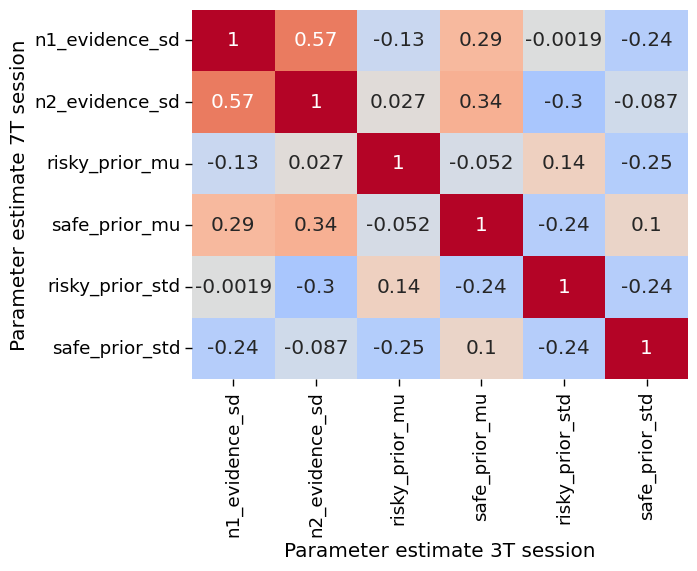

In [189]:
g = sns.heatmap(results.loc['data'].groupby(['subject', 'parameter'])['ground truth'].mean().unstack().corr().loc[parameter_labels, parameter_labels], annot=True, vmin=-.9, vmax=.9, cmap='coolwarm',
            cbar=False)

g.set_xlabel('Parameter estimate 3T session')
g.set_ylabel('Parameter estimate 7T session')

Text(44.65104166666666, 0.5, 'Generating')

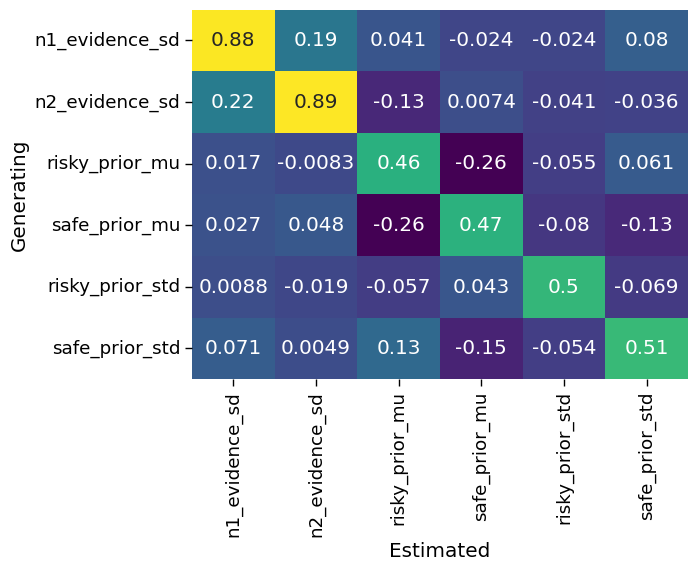

In [190]:
import matplotlib.pyplot as plt
r = results.groupby(['parameter_source', 'use_calibrated_design', 'simulation_ix']).apply(lambda x: x.unstack('parameter')[['mean', 'ground truth']].corr().loc[['ground truth'], ['mean']])

r = r.groupby(['parameter_source', 'use_calibrated_design', 'parameter']).mean()

g = sns.heatmap(r.loc[('prior', False)].droplevel(0, axis=1).loc[parameter_labels, parameter_labels], annot=True, cmap='viridis', cbar=False)

g.set_xlabel('Estimated')
g.set_ylabel('Generating')

In [226]:


parameters = ['risky_prior_mu', 'safe_prior_mu', 'risky_prior_std', 'safe_prior_std']


rs = []

recovery = []

for parameter in parameter_labels:
    tmp = results.loc['prior'].unstack('parameter')[[('mean', parameter), ('ground truth', parameter), ('ground truth', 'n1_evidence_sd'), ('ground truth', 'n2_evidence_sd'),
                                                     ('ground truth', 'risky_prior_mu'), ('ground truth', 'safe_prior_mu'),
                                                     ('ground truth', 'risky_prior_std'), ('ground truth', 'safe_prior_std')]]

    tmp.columns = [f'estimate', f'ground truth', 'n1 evidence sd (ground truth)', 'n2 evidence sd (ground truth)', 'risky_prior_mu (ground truth)', 'safe_prior_mu (ground truth)',
                   'risky_prior_std (ground truth)', 'safe_prior_std (ground truth)']

    tmp['difference_evidence'] = (tmp['n1 evidence sd (ground truth)'] - tmp['n2 evidence sd (ground truth)']).abs()
    tmp['difference_prior_mus'] = (tmp['risky_prior_mu (ground truth)'] - tmp['safe_prior_mu (ground truth)']).abs()
    tmp['difference_prior_stds'] = (tmp['risky_prior_std (ground truth)'] - tmp['safe_prior_std (ground truth)']).abs()

    tmp['bin(difference_evidence)'] = pd.qcut(tmp['difference_evidence'], 5, labels=['very low', 'low', 'medium', 'high', 'very high'])
    tmp['bin(difference_prior_mus)'] = pd.qcut(tmp['difference_prior_mus'], 5, labels=['very low', 'low', 'medium', 'high', 'very high'])
    tmp['bin(difference_prior_stds)'] = pd.qcut(tmp['difference_prior_stds'], 5, labels=['very low', 'low', 'medium', 'high', 'very high'])

    recovery.append(tmp)

    rs.append(tmp.groupby('bin(difference_evidence)').apply(lambda x: x[[f'estimate', f'ground truth']].corr().iloc[0, 1]))


rs = pd.concat(rs, axis=1, keys=parameter_labels)

recovery = pd.concat(recovery, axis=0, keys=parameter_labels, names=['parameter'])

# sns.lmplot(x=f'ground truth', y=f'estimate', col='parameter', col_wrap=2, hue='bin(difference_evidence)', data=results.reset_index(), palette='coolwarm', scatter_kws={'alpha': .75})

# plt.plot(plt.xlim(), plt.xlim(), ls="--", c=".3")
# plt.title(parameter.capitalize())
# plt.show()

/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


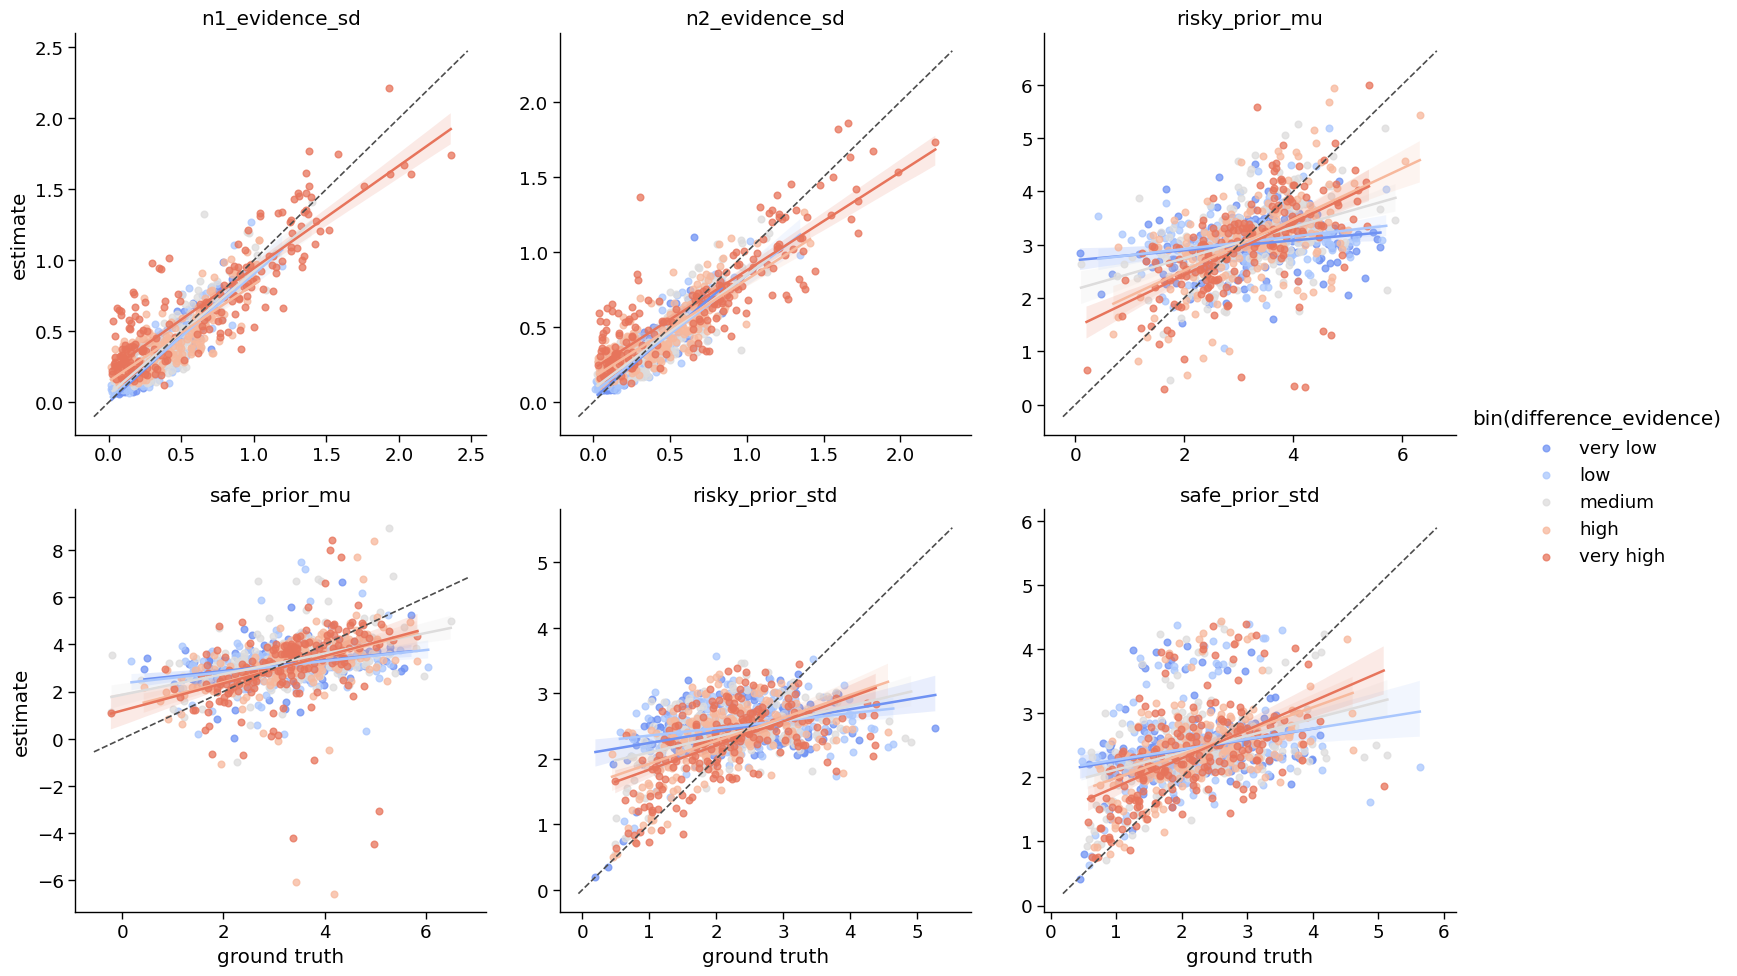

In [227]:
g = sns.lmplot(x='ground truth', y='estimate', data=recovery.reset_index(), col='parameter', sharex=False, sharey=False, hue='bin(difference_evidence)', palette='coolwarm', scatter_kws={'alpha': .75},
           col_wrap=3)

g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.plot(ax.get_xlim(), ax.get_xlim(), ls="--", c=".3")

/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


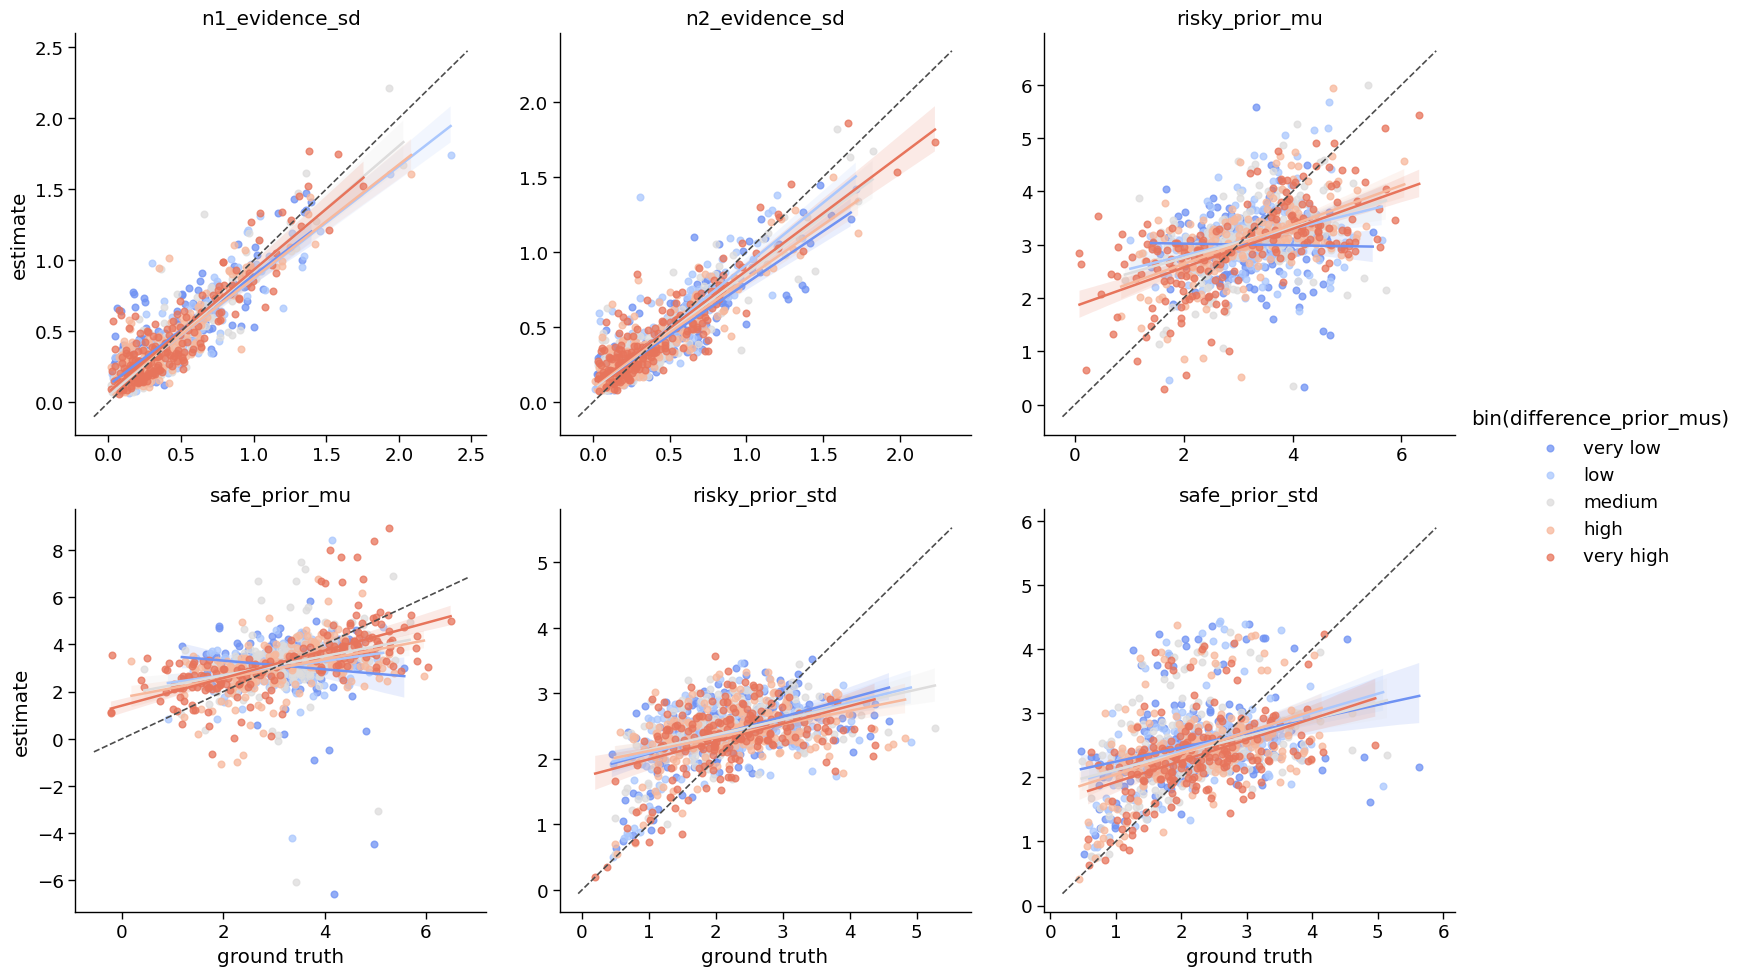

In [228]:
g = sns.lmplot(x='ground truth', y='estimate', data=recovery.reset_index(), col='parameter', sharex=False, sharey=False, hue='bin(difference_prior_mus)', palette='coolwarm', scatter_kws={'alpha': .75},
           col_wrap=3)

g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.plot(ax.get_xlim(), ax.get_xlim(), ls="--", c=".3")

/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


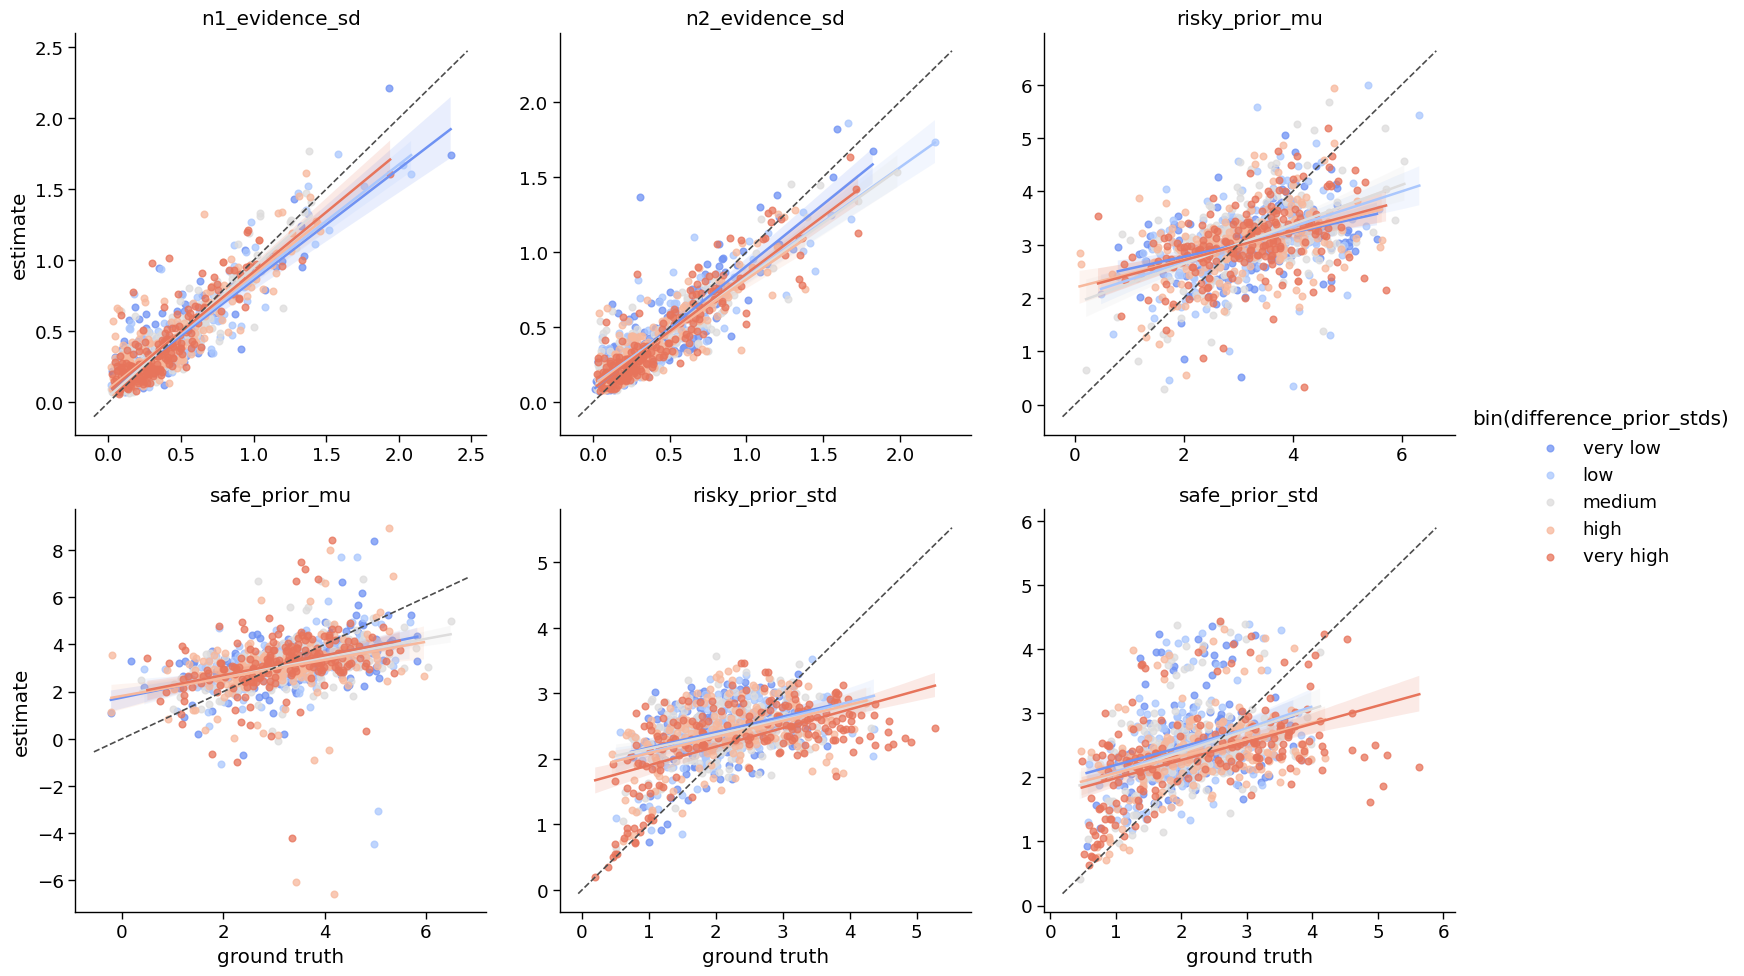

In [229]:
g = sns.lmplot(x='ground truth', y='estimate', data=recovery.reset_index(), col='parameter', sharex=False, sharey=False, hue='bin(difference_prior_stds)', palette='coolwarm', scatter_kws={'alpha': .75},
           col_wrap=3)

g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.plot(ax.get_xlim(), ax.get_xlim(), ls="--", c=".3")

In [232]:
rs.round(3).to_clipboard()

In [196]:
recovery

risky_prior_mu (estimate)  \
parameter      use_calibrated_design simulation_ix subject                              
risky_prior_mu False                 1             1                         2.766658   
                                                   2                         2.748508   
                                                   3                         2.920136   
                                                   4                         2.973732   
                                                   5                         1.741272   
...                                                                               ...   
safe_prior_std False                 10            96                             NaN   
                                                   97                             NaN   
                                                   98                             NaN   
                                                   99                             NaN   
                                                   100                            NaN   

                                                            risky_prior_mu (ground truth)  \
parameter      use_calibrated_design simulation_ix subject                                  
risky_prior_mu False                 1             1                             3.817769   
                                                   2                             3.798791   
                                                   3                             3.609106   
                                                   4                             1.403886   
                                                   5                             2.776307   
...                                                                                   ...   
safe_prior_std False                 10            96                                 NaN   
                                                   97                                 NaN   
                                                   98                                 NaN   
                                                   99                                 NaN   
                                                   100                                NaN   

                                                            n1 evidence sd (ground truth)  \
parameter      use_calibrated_design simulation_ix subject                                  
risky_prior_mu False                 1             1                             0.016482   
                                                   2                             0.436353   
                                                   3                             0.319774   
                                                   4                             0.090133   
                                                   5                             0.325160   
...                                                                                   ...   
safe_prior_std False                 10            96                            0.110581   
                                                   97                            0.326058   
                                                   98                            0.203231   
                                                   99                            0.018142   
                                                   100                           0.121284   

                                                            n2 evidence sd (ground truth)  \
parameter      use_calibrated_design simulation_ix subject                                  
risky_prior_mu False                 1             1                             0.198959   
                                                   2                             0.672690   
                                                   3                             0.803345   
                 

In [192]:
rs

,risky_prior_mu,safe_prior_mu,risky_prior_std,safe_prior_std
bin(difference_evidence),,,,
very low,0.213520,0.314747,0.360890,0.255751
low,0.229076,0.267955,0.271700,0.214015
medium,0.430336,0.440952,0.448086,0.385044
high,0.564558,0.402670,0.505291,0.469693
very high,0.563179,0.370773,0.553254,0.507589


# Across-session correlation

In [148]:
idata_3t = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', 'ses-3t2_model-1_trace.netcdf'))
idata_7t = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', 'ses-7t2_model-1_trace.netcdf'))

In [149]:
parameter_estimates = pd.concat((idata_3t.posterior[parameter_labels].to_dataframe().groupby('subject').mean(),
              idata_7t.posterior[parameter_labels].to_dataframe().groupby('subject').mean()), keys=['3t', '7t'], names=['field_strength']).unstack('field_strength')
parameter_estimates.columns.set_names('parameter', level=0, inplace=True)

In [153]:
import pingouin
correlation_table = parameter_estimates.groupby('parameter', axis=1).apply(lambda d: pingouin.corr(d.droplevel(0, 1)['3t'], d.droplevel(0, 1)['7t'])).stack(1).T['pearson']

correlation_table.to_clipboard()


In [151]:
corr_sessions = parameter_estimates.corr().loc[(slice(None), '3t'), (slice(None), '7t')]

Text(50.58159722222221, 0.5, 'Parameter 3T')

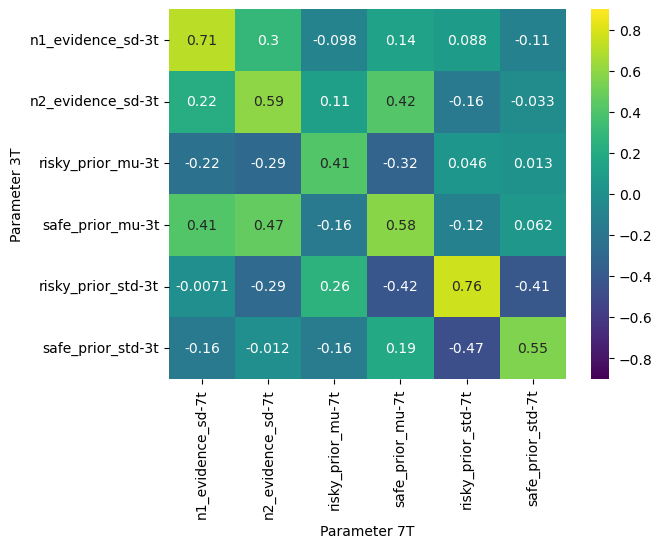

In [133]:
g = sns.heatmap(corr_sessions, annot=True, cmap='viridis', vmin=-.9, vmax=.9)

g.set_xlabel('Parameter 7T')
g.set_ylabel('Parameter 3T')

In [103]:
idata_full = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', 'model-12_trace.netcdf'))
# idata_7t = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', 'ses-7t2_model-1_trace.netcdf'))

parameter
n1_evidence_sd_mu     0.934500
n2_evidence_sd_mu     0.924500
risky_prior_mu_mu     0.511500
risky_prior_std_mu    0.928000
safe_prior_mu_mu      0.861500
safe_prior_std_mu     0.968167
dtype: float64

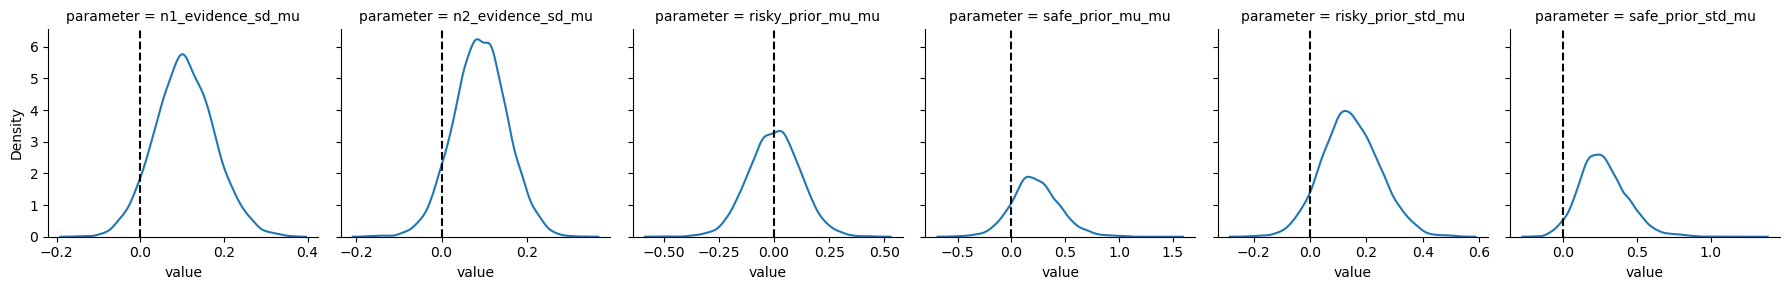

In [124]:
session_effect = []
for parameter in parameter_labels:

    session_effect.append(idata_full.posterior[parameter+'_mu'].to_dataframe().xs('session[T.7t2]', level=f'{parameter}_regressors'))

session_effect = pd.concat(session_effect, axis=1, names=['paraemter'] )

tmp = session_effect.stack().to_frame('value')
tmp.index.set_names('parameter', level=-1, inplace=True)

g = sns.FacetGrid(tmp.reset_index(), col='parameter', sharex=False)

g.map(sns.kdeplot, 'value')
g.map(plt.axvline, x=0, c='k', ls='--')

tmp.groupby('parameter').apply(lambda x: (x['value'] > 0.0).mean())